#   Word-Level的图表和词云

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2
import scipy.sparse as sp
from time import time
import numpy as np
import json
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def normalize(data):
    return data

def ngrams(train, test, labels, ntrain, mn=1, mx=1, nm=500, binary = False, donorm = False, stopwords = False, verbose = True, analyzer_char = False):
    
    ftrain = train
    ftest  = test
    y_train = labels
    
    t0 = time()
    analyzer_type = 'word'
    if analyzer_char:
        analyzer_type = 'char'
        
    if binary:
        vectorizer = CountVectorizer(ngram_range=(mn, mx))
    elif stopwords:
        vectorizer = TfidfVectorizer(max_n=mx,min_n=mn,stop_words='english',analyzer=analyzer_type,sublinear_tf=True)
    else:
        # TfidfVectorizer 是一个用于将文本数据转换为 TF-IDF 特征表示的类，将文本中的词语转换为向量形式，用于机器学习算法的输入
        vectorizer = TfidfVectorizer(ngram_range=(mn,mx),sublinear_tf=True,analyzer=analyzer_type)

    # 打印详细信息
    if verbose:
        print("extracting ngrams... where n is [%d,%d]" % (mn,mx))
    
    X_train = vectorizer.fit_transform(ftrain)
    X_test = vectorizer.transform(ftest)
    feature_names = vectorizer.get_feature_names_out().tolist()  
    
    if verbose:
        print("done in %fs" % (time() - t0), X_train.shape, X_test.shape)

    y = np.array(y_train)    
    
    numFts = nm
    if numFts < X_train.shape[1]:
        ch2 = SelectKBest(chi2, k=numFts)
        X_train = ch2.fit_transform(X_train, y)
        X_test = ch2.transform(X_test)
        # 断言X_train是否为稀疏矩阵，若否，则程序中断执行
        assert sp.issparse(X_train) 

    selected_feature_indices = ch2.get_support(indices=True)
    selected_feature_names = [feature_names[idx] for idx in selected_feature_indices]
    feature_scores = ch2.scores_[selected_feature_indices]
    # 创建一个包含特征名称和对应权重分数的元组列表
    feature_names_scores = list(zip(selected_feature_names, feature_scores))

    # 根据权重分数对特征名称进行排序
    sorted_features = sorted(feature_names_scores, key=lambda x: x[1], reverse=True)
    # 排除索引为5的特征
    sorted_features_without_sixth = [feature for i, feature in enumerate(sorted_features) if i != 5 and i!=6]

    # 获取排序后的前 10 条特征及其分数
    top_features = sorted_features_without_sixth[:10]
    top_feature_names, top_feature_scores = zip(*top_features)
    # 绘制柱状图
    plt.figure(figsize=(12, 8))
    plt.bar(top_feature_names, top_feature_scores)  # 调整柱子宽度
    plt.xlabel('Word-level features on the eRisk2017 dataset', fontsize=24)
    plt.ylabel('Correlation scores', fontsize=24)
    # plt.title('Chi-squared Analysis for Depression Correlation', fontsize=20)
    plt.xticks(rotation=45, ha="right", fontsize=22)  # 调整横坐标标签的显示角度和对齐方式
    plt.yticks(fontsize=22)  # 设置纵坐标刻度标签的字体大小
    plt.tight_layout()  # 自动调整子图参数，以便显示完整
    plt.savefig('chi_word17.png')

    # 生成词云
    feature_names, feature_scores = zip(*sorted_features_without_sixth)
    colormap = 'viridis'
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=colormap).generate_from_frequencies(dict(zip(feature_names, feature_scores)))
    wordcloud.to_file("wordcloud_word17.png")
        
    # selected_indices = ch2.get_support(indices=True)  # 获取所选特征的索引
    # selected_feature_names = [feature_names[i] for i in selected_indices]  # 根据索引获取所选特征的名称
    if verbose:
        print("Extracting best features by a chi-squared test.. ", X_train.shape, X_test.shape) 
    data={}
    # data['train']=X_train.toarray().tolist()
    # data['y']=y.tolist()
    # data['X_test']=X_test.toarray().tolist()
    #data['names']=names.tolist()   
    
    # with open('/home/E22301339/depressionDetection-eRisk2018/processedData/data.json','w')as f:
    #     json.dump(data,f)
    print("........................end")
    return X_train, y, X_test

if __name__ == '__main__':
    print("..........................loading")

        #  读取训练集数据
    with open('/home/E22301339/depressionDetection/processedData/total_user_wordpost.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())

    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    train=data

        #  读取训练集数据(子情绪序列)
    with open('/home/E22301339/depressionDetection/codes-author/data/train2.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())

    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    train2=data

    #  读取测试集数据
    with open('/home/E22301339/depressionDetection/processedData/total_user_wordpost2.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())
    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    test=data

        #  读取测试集数据(子情绪序列)
    with open('/home/E22301339/depressionDetection/codes-author/data/test2.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())
    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    test2=data

    #   训练集标签
    with open ('/home/E22301339/depressionDetection/features/risk_golden_truth.txt','r+')as f:
            list_data=[]
            list_total=[]  # 存储positive抑郁的用户id
            for item in f.readlines():
                list_data.append(item.strip())
    str=list_data[0][:-1].strip()
        # print(str)
        # print(list_data[0][len(list_data[0])-1])

    for item in list_data:
        print(item)
        if(item[len(item)-1]=='1'):
            list_total.append(item[:-1].strip())

    with open('/home/E22301339/depressionDetection/processedData/user_features_train.json','r')as f:
            users=list(json.load(f).keys())
    labels=[]
    for user in users:
        if user in list_total:
            labels.append(1)
        else:
            labels.append(0)



    ntrain = len(train)

    verbose = True

    t0 = time()

    X_train, y_train, X_test = ngrams(train, test, labels, ntrain, 1, 1, 300, donorm = True, verbose = verbose) #min_ngram, max_ngram, size of final vector
    X_train2, y_train, X_test2 = ngrams(train2, test2, labels, ntrain, 1, 1, 1200, donorm = True, verbose = verbose) #char ngrams   

    TR_DDR = sp.hstack([X_train])
    TE_DDR = sp.hstack([X_test])

    TR_DDR = sp.hstack([X_train,X_train2]) #combine different vectors
    TE_DDR = sp.hstack([X_test,X_test2])

    data={}
    data['train']=TR_DDR.toarray().tolist()
    data['y']=labels
    data['X_test']=TE_DDR.toarray().tolist()  
    with open('/home/E22301339/depressionDetection/processedData/data4.json','w')as f:
        json.dump(data,f)

    if verbose:
        print("######## Total time for feature extraction: %fs" % (time() - t0), TR_DDR.shape, TE_DDR.shape)

#   Topic-Level的图表和词云

KeyboardInterrupt: 

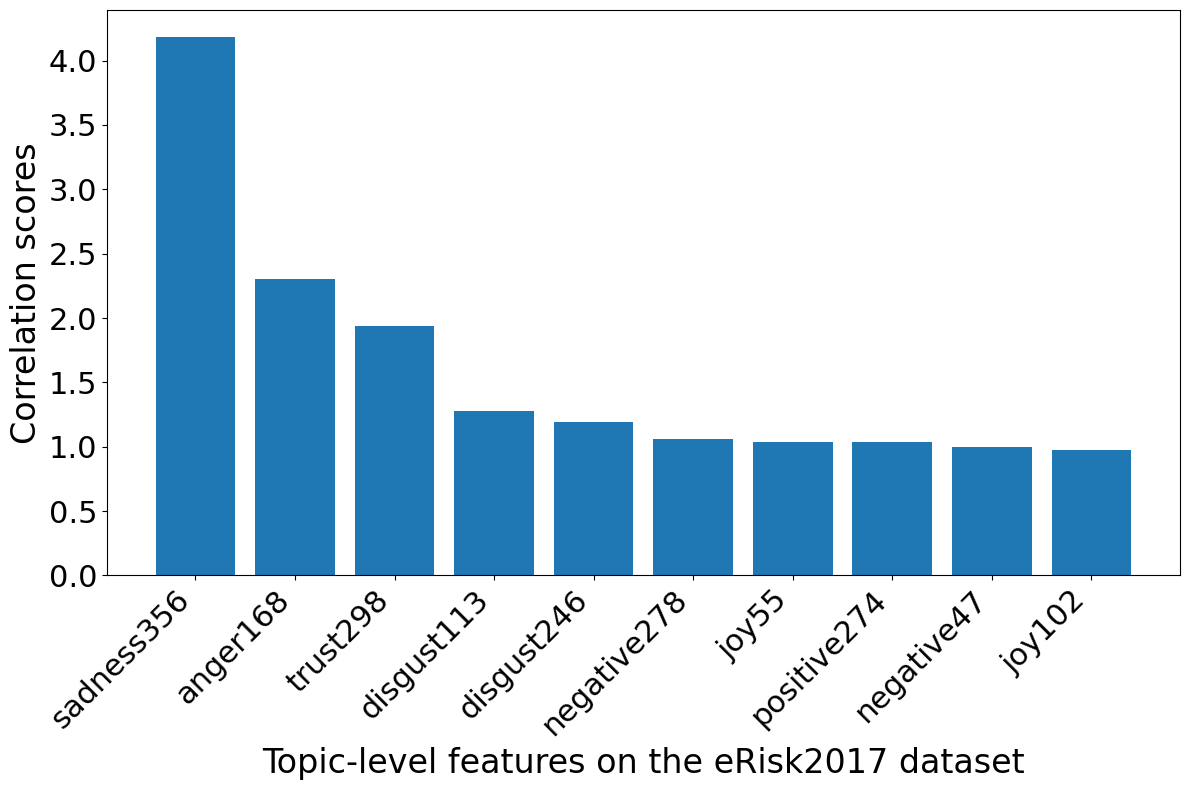

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2
import scipy.sparse as sp
from time import time
import numpy as np
import json
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def normalize(data):
    return data

def ngrams(train, test, labels, ntrain, mn=1, mx=1, nm=500, binary = False, donorm = False, stopwords = False, verbose = True, analyzer_char = False):
    
    ftrain = train
    ftest  = test
    y_train = labels
    
    t0 = time()
    analyzer_type = 'word'
    if analyzer_char:
        analyzer_type = 'char'
        
    if binary:
        vectorizer = CountVectorizer(ngram_range=(mn, mx))
    elif stopwords:
        vectorizer = TfidfVectorizer(max_n=mx,min_n=mn,stop_words='english',analyzer=analyzer_type,sublinear_tf=True)
    else:
        # TfidfVectorizer 是一个用于将文本数据转换为 TF-IDF 特征表示的类，将文本中的词语转换为向量形式，用于机器学习算法的输入
        vectorizer = TfidfVectorizer(ngram_range=(mn,mx),sublinear_tf=True,analyzer=analyzer_type)

    # 打印详细信息
    if verbose:
        print("extracting ngrams... where n is [%d,%d]" % (mn,mx))
    
    X_train = vectorizer.fit_transform(ftrain)
    X_test = vectorizer.transform(ftest)
    feature_names = vectorizer.get_feature_names_out().tolist()  
    
    if verbose:
        print("done in %fs" % (time() - t0), X_train.shape, X_test.shape)

    y = np.array(y_train)    
    
    numFts = nm
    if numFts < X_train.shape[1]:
        ch2 = SelectKBest(chi2, k=numFts)
        X_train = ch2.fit_transform(X_train, y)
        X_test = ch2.transform(X_test)
        # 断言X_train是否为稀疏矩阵，若否，则程序中断执行
        assert sp.issparse(X_train) 

    selected_feature_indices = ch2.get_support(indices=True)
    selected_feature_names = [feature_names[idx] for idx in selected_feature_indices]
    feature_scores = ch2.scores_[selected_feature_indices]
    # 创建一个包含特征名称和对应权重分数的元组列表
    feature_names_scores = list(zip(selected_feature_names, feature_scores))

    # 根据权重分数对特征名称进行排序
    sorted_features = sorted(feature_names_scores, key=lambda x: x[1], reverse=True)
    # 排除索引为5的特征
    sorted_features_without_sixth = [feature for i, feature in enumerate(sorted_features) if i != 1 and i!=4]

    # 获取排序后的前 10 条特征及其分数
    top_features = sorted_features_without_sixth[:10]
    top_feature_names, top_feature_scores = zip(*top_features)
    # 绘制柱状图
    plt.figure(figsize=(12, 8))
    plt.bar(top_feature_names, top_feature_scores)  # 调整柱子宽度
    plt.xlabel('Topic-level features on the eRisk2017 dataset', fontsize=24)
    plt.ylabel('Correlation scores', fontsize=24)
    # plt.title('Chi-squared Analysis for Depression Correlation', fontsize=20)
    plt.xticks(rotation=45, ha="right", fontsize=22)  # 调整横坐标标签的显示角度和对齐方式
    plt.yticks(fontsize=22)  # 设置纵坐标刻度标签的字体大小
    plt.tight_layout()  # 自动调整子图参数，以便显示完整
    plt.savefig('chi_emotion17.png')

    # 生成词云
    feature_names, feature_scores = zip(*sorted_features_without_sixth)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(feature_names, feature_scores)))
    wordcloud.to_file("wordcloud_emotion17.png")
        
    # selected_indices = ch2.get_support(indices=True)  # 获取所选特征的索引
    # selected_feature_names = [feature_names[i] for i in selected_indices]  # 根据索引获取所选特征的名称
    if verbose:
        print("Extracting best features by a chi-squared test.. ", X_train.shape, X_test.shape) 
    data={}
    # data['train']=X_train.toarray().tolist()
    # data['y']=y.tolist()
    # data['X_test']=X_test.toarray().tolist()
    #data['names']=names.tolist()   
    
    # with open('/home/E22301339/depressionDetection-eRisk2018/processedData/data.json','w')as f:
    #     json.dump(data,f)
    print("........................end")
    return X_train, y, X_test

if __name__ == '__main__':
    print("..........................loading")

        #  读取训练集数据
    with open('/home/E22301339/depressionDetection/processedData/total_user_wordpost.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())

    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    train=data

        #  读取训练集数据(子情绪序列)
    with open('/home/E22301339/depressionDetection/codes-author/data/train2.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())

    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    train2=data

    #  读取测试集数据
    with open('/home/E22301339/depressionDetection/processedData/total_user_wordpost2.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())
    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    test=data

        #  读取测试集数据(子情绪序列)
    with open('/home/E22301339/depressionDetection/codes-author/data/test2.json', 'r') as f:
        data = json.load(f)
    data=list(data.values())
    for i in range(len(data)):
        data[i]=' '.join(data[i]).strip()
    test2=data

    #   训练集标签
    with open ('/home/E22301339/depressionDetection/features/risk_golden_truth.txt','r+')as f:
            list_data=[]
            list_total=[]  # 存储positive抑郁的用户id
            for item in f.readlines():
                list_data.append(item.strip())
    str=list_data[0][:-1].strip()
        # print(str)
        # print(list_data[0][len(list_data[0])-1])

    for item in list_data:
        print(item)
        if(item[len(item)-1]=='1'):
            list_total.append(item[:-1].strip())

    with open('/home/E22301339/depressionDetection/processedData/user_features_train.json','r')as f:
            users=list(json.load(f).keys())
    labels=[]
    for user in users:
        if user in list_total:
            labels.append(1)
        else:
            labels.append(0)



    ntrain = len(train)

    verbose = True

    t0 = time()

    #   X_train, y_train, X_test = ngrams(train, test, labels, ntrain, 1, 1, 300, donorm = True, verbose = verbose) #min_ngram, max_ngram, size of final vector
    X_train2, y_train, X_test2 = ngrams(train2, test2, labels, ntrain, 1, 1, 1200, donorm = True, verbose = verbose) #char ngrams   

    # TR_DDR = sp.hstack([X_train])
    # TE_DDR = sp.hstack([X_test])

    # TR_DDR = sp.hstack([X_train,X_train2]) #combine different vectors
    # TE_DDR = sp.hstack([X_test,X_test2])

    # data={}
    # data['train']=TR_DDR.toarray().tolist()
    # data['y']=labels
    # data['X_test']=TE_DDR.toarray().tolist()  
    # with open('/home/E22301339/depressionDetection-eRisk2018/processedData/data3.json','w')as f:
    #     json.dump(data,f)

    if verbose:
        print("######## Total time for feature extraction: %fs" % (time() - t0), TR_DDR.shape, TE_DDR.shape)